In [1]:
from pathlib import Path

import geopandas as gpd
import pandas as pd
import requests
import xarray as xr

PROJECT_ROOT = Path(r"Z:\Projects\monsoon-postprocessing")

PROCESSED_FOLDER = PROJECT_ROOT / "data" / "processed"
BOUNDARY_FOLDER = PROJECT_ROOT / "data" / "boundaries"
BOUNDARY_FOLDER.mkdir(parents=True, exist_ok=True)

MODEL_FILE = PROCESSED_FOLDER / "july2018_model_dataset.nc"
PROBABILITY_FILE = PROCESSED_FOLDER / "heavy_rain_probability_test.nc"
DISTRICT_FILE = BOUNDARY_FOLDER / "india_adm2.geojson"

In [2]:
API_URL = "https://www.geoboundaries.org/api/current/gbOpen/IND/ADM2/"

if not DISTRICT_FILE.exists():
    metadata_response = requests.get(API_URL, timeout=60)
    metadata_response.raise_for_status()
    metadata = metadata_response.json()

    download_url = metadata["gjDownloadURL"]

    boundary_response = requests.get(download_url, timeout=180)
    boundary_response.raise_for_status()

    DISTRICT_FILE.write_bytes(boundary_response.content)

print("Boundary file exists:", DISTRICT_FILE.exists())
print("Location:", DISTRICT_FILE)

Boundary file exists: True
Location: Z:\Projects\monsoon-postprocessing\data\boundaries\india_adm2.geojson


In [3]:
districts = gpd.read_file(DISTRICT_FILE)

districts = districts.to_crs("EPSG:4326")

print(districts)
print("\nColumns:", list(districts.columns))
print("CRS:", districts.crs)
print("Number of districts:", len(districts))
print("\nSample district names:")
print(districts["shapeName"].head(10))

                   shapeName shapeISO                  shapeID shapeGroup  \
0                 Ashoknagar           76128533B75548370501185        IND   
1                     Raisen           76128533B57893545331548        IND   
2                 Chhindwara           76128533B70646408240587        IND   
3                      Betul           76128533B82559220423608        IND   
4                Hoshangabad           76128533B45314020251888        IND   
..                       ...      ...                      ...        ...   
730             Chengalputtu           76128533B88669134807148        IND   
731             Kallakurichi           76128533B19545859035458        IND   
732           Mayiladuthurai           76128533B63176236753619        IND   
733                  Tenkasi           76128533B27604563137530        IND   
734  Gaurella Pendra Marwahi           76128533B38203190611533        IND   

    shapeType                                           geometry  
0       

In [4]:
import numpy as np

with xr.open_dataset(MODEL_FILE) as dataset:
    rainfall_ds = dataset[
        ["gefs_rainfall", "imerg_rainfall"]
    ].sel(
        date=slice("2018-07-27", "2018-07-31")
    ).load()

with xr.open_dataset(PROBABILITY_FILE) as dataset:
    probability_ds = dataset.load()

print("Rainfall dataset:")
print(rainfall_ds)

print("\nProbability dataset:")
print(probability_ds)

Rainfall dataset:
<xarray.Dataset> Size: 626kB
Dimensions:         (date: 5, latitude: 129, longitude: 121)
Coordinates:
  * date            (date) datetime64[ns] 40B 2018-07-27 ... 2018-07-31
  * latitude        (latitude) float64 1kB 6.0 6.25 6.5 6.75 ... 37.5 37.75 38.0
  * longitude       (longitude) float64 968B 68.0 68.25 68.5 ... 97.5 97.75 98.0
Data variables:
    gefs_rainfall   (date, latitude, longitude) float32 312kB 0.63 0.74 ... 1.35
    imerg_rainfall  (date, latitude, longitude) float32 312kB nan nan ... nan
Attributes:
    title:                   July 2018 regime-aware model dataset
    rainfall_forecast:       GEFS +24 to +48 hours
    atmospheric_predictors:  GEFS forecast hour 36
    observation:             NASA GPM IMERG Final

Probability dataset:
<xarray.Dataset> Size: 939kB
Dimensions:                      (date: 5, latitude: 129, longitude: 121)
Coordinates:
  * date                         (date) datetime64[ns] 40B 2018-07-27 ... 201...
  * latitude         

In [5]:
longitude_grid, latitude_grid = np.meshgrid(
    rainfall_ds.longitude.values,
    rainfall_ds.latitude.values,
)

grid_points = gpd.GeoDataFrame(
    {
        "longitude": longitude_grid.ravel(),
        "latitude": latitude_grid.ravel(),
    },
    geometry=gpd.points_from_xy(
        longitude_grid.ravel(),
        latitude_grid.ravel(),
    ),
    crs="EPSG:4326",
)

print("Total rectangular grid points:", len(grid_points))

Total rectangular grid points: 15609


In [6]:
district_columns = [
    "shapeName",
    "shapeID",
    "geometry",
]

grid_district_lookup = gpd.sjoin(
    grid_points,
    districts[district_columns],
    how="inner",
    predicate="within",
)

grid_district_lookup = grid_district_lookup.drop(
    columns=["index_right"]
).reset_index(drop=True)

represented_districts = grid_district_lookup["shapeID"].nunique()
missing_districts = len(districts) - represented_districts

print("Grid points inside India:", len(grid_district_lookup))
print("Districts represented:", represented_districts)
print("Districts without a grid-centre point:", missing_districts)

grid_district_lookup.head()

Grid points inside India: 4652
Districts represented: 707
Districts without a grid-centre point: 28


,longitude,latitude,geometry,shapeName,shapeID
0,93.75,7.00,POINT (93.75 7),Nicobars,76128533B33103505211400
1,93.50,8.00,POINT (93.5 8),Nicobars,76128533B33103505211400
2,77.25,8.25,POINT (77.25 8.25),Kanniyakumari,76128533B53796141759805
3,77.50,8.25,POINT (77.5 8.25),Kanniyakumari,76128533B53796141759805
4,77.75,8.25,POINT (77.75 8.25),Tirunelveli,76128533B52639434516056


In [7]:
LOOKUP_FILE = PROCESSED_FOLDER / "gefs_grid_district_lookup.csv"

grid_district_lookup[
    [
        "latitude",
        "longitude",
        "shapeName",
        "shapeID",
    ]
].to_csv(
    LOOKUP_FILE,
    index=False,
)

print("Saved:", LOOKUP_FILE.exists())
print("Location:", LOOKUP_FILE)

Saved: True
Location: Z:\Projects\monsoon-postprocessing\data\processed\gefs_grid_district_lookup.csv


In [9]:
represented_ids = set(grid_district_lookup["shapeID"])

missing_district_data = districts[
    ~districts["shapeID"].isin(represented_ids)
].copy()

fallback_rows = []

for district in missing_district_data.itertuples():
    point = district.geometry.representative_point()

    nearest_latitude = rainfall_ds.latitude.sel(
        latitude=point.y,
        method="nearest",
    ).item()

    nearest_longitude = rainfall_ds.longitude.sel(
        longitude=point.x,
        method="nearest",
    ).item()

    fallback_rows.append(
        {
            "latitude": nearest_latitude,
            "longitude": nearest_longitude,
            "shapeName": district.shapeName,
            "shapeID": district.shapeID,
            "mapping_method": "nearest_grid",
        }
    )

contained_lookup = grid_district_lookup[
    ["latitude", "longitude", "shapeName", "shapeID"]
].copy()

contained_lookup["mapping_method"] = "contained_grid"

complete_lookup = pd.concat(
    [
        contained_lookup,
        pd.DataFrame(fallback_rows),
    ],
    ignore_index=True,
)

print("Total mapping rows:", len(complete_lookup))
print("Districts represented:", complete_lookup["shapeID"].nunique())
print(complete_lookup["mapping_method"].value_counts())

Total mapping rows: 4680
Districts represented: 735
mapping_method
contained_grid    4652
nearest_grid        28
Name: count, dtype: int64


In [10]:
combined_grid = xr.merge(
    [
        rainfall_ds,
        probability_ds[
            [
                "heavy_rain_probability",
                "very_heavy_rain_probability",
            ]
        ],
    ],
    join="exact",
)

grid_table = combined_grid.to_dataframe().reset_index()

district_grid_table = grid_table.merge(
    complete_lookup,
    on=["latitude", "longitude"],
    how="inner",
)

print("Rows after district mapping:", len(district_grid_table))
print("Dates:", district_grid_table["date"].nunique())
print("Districts:", district_grid_table["shapeID"].nunique())

district_grid_table.head()

Rows after district mapping: 23400
Dates: 5
Districts: 735


,date,latitude,longitude,gefs_rainfall,imerg_rainfall,heavy_rain_probability,very_heavy_rain_probability,shapeName,shapeID,mapping_method
0,2018-07-27,7.00,93.75,18.389999,39.894997,0.001218,0.000090,Nicobars,76128533B33103505211400,contained_grid
1,2018-07-27,8.00,93.50,13.840001,2.513750,0.000675,0.000058,Nicobars,76128533B33103505211400,contained_grid
2,2018-07-27,8.25,77.25,0.070000,0.005000,0.000058,0.000006,Kanniyakumari,76128533B53796141759805,contained_grid
3,2018-07-27,8.25,77.50,0.000000,0.315000,0.000057,0.000007,Kanniyakumari,76128533B53796141759805,contained_grid
4,2018-07-27,8.25,77.75,0.000000,0.000000,0.000042,0.000011,Tirunelveli,76128533B52639434516056,contained_grid


In [11]:
district_daily = (
    district_grid_table
    .groupby(
        [
            "date",
            "shapeID",
            "shapeName",
            "mapping_method",
        ],
        as_index=False,
    )
    .agg(
        gefs_mean_mm=("gefs_rainfall", "mean"),
        gefs_max_mm=("gefs_rainfall", "max"),
        observed_mean_mm=("imerg_rainfall", "mean"),
        observed_max_mm=("imerg_rainfall", "max"),
        heavy_probability_mean=(
            "heavy_rain_probability",
            "mean",
        ),
        heavy_probability_max=(
            "heavy_rain_probability",
            "max",
        ),
        very_heavy_probability_max=(
            "very_heavy_rain_probability",
            "max",
        ),
        grid_cells=("latitude", "count"),
    )
)

print("District-date rows:", len(district_daily))
print("Dates:", district_daily["date"].nunique())
print("Districts:", district_daily["shapeID"].nunique())

district_daily.head()

District-date rows: 3675
Dates: 5
Districts: 735


,date,shapeID,shapeName,mapping_method,gefs_mean_mm,gefs_max_mm,observed_mean_mm,observed_max_mm,heavy_probability_mean,heavy_probability_max,very_heavy_probability_max,grid_cells
0,2018-07-27,76128533B10270619600482,South District,nearest_grid,15.790001,15.790001,5.585000,5.585,0.028315,0.028315,0.000337,1
1,2018-07-27,76128533B10727492375508,Fatehabad,contained_grid,9.372500,16.150002,0.092813,0.300,0.005704,0.006139,0.000333,4
2,2018-07-27,76128533B1083016608278,Gulbarga,contained_grid,0.632000,1.020000,0.112250,1.290,0.000144,0.000152,0.000025,15
3,2018-07-27,76128533B11082155919544,Rajsamand,contained_grid,0.412857,0.890000,0.000000,0.000,0.000372,0.000526,0.000057,7
4,2018-07-27,76128533B11083100419963,Mahoba,contained_grid,1.782500,2.510000,2.058750,3.025,0.001674,0.003802,0.000106,4


In [12]:
def assign_risk(row):
    if row["heavy_probability_max"] >= 0.10:
        return "Heavy Rain Watch"

    return "Low Modelled Signal"


district_daily["risk_level"] = district_daily.apply(
    assign_risk,
    axis=1,
)

district_daily["very_heavy_experimental"] = (
    district_daily["very_heavy_probability_max"] >= 0.05
)

print(district_daily["risk_level"].value_counts())

print("\nExperimental very-heavy signals:")
print(district_daily["very_heavy_experimental"].value_counts())

risk_level
Low Modelled Signal    3553
Heavy Rain Watch        122
Name: count, dtype: int64

Experimental very-heavy signals:
very_heavy_experimental
False    3673
True        2
Name: count, dtype: int64


In [13]:
DISTRICT_CSV = (
    PROCESSED_FOLDER
    / "district_rainfall_forecast_20180727_20180731.csv"
)

COMPLETE_LOOKUP_FILE = (
    PROCESSED_FOLDER
    / "complete_grid_district_lookup.csv"
)

district_daily.to_csv(
    DISTRICT_CSV,
    index=False,
)

complete_lookup.to_csv(
    COMPLETE_LOOKUP_FILE,
    index=False,
)

print("District forecast saved:", DISTRICT_CSV.exists())
print("Forecast location:", DISTRICT_CSV)
print("Lookup saved:", COMPLETE_LOOKUP_FILE.exists())

District forecast saved: True
Forecast location: Z:\Projects\monsoon-postprocessing\data\processed\district_rainfall_forecast_20180727_20180731.csv
Lookup saved: True


In [14]:
highest_risk = district_daily.sort_values(
    [
        "date",
        "heavy_probability_max",
    ],
    ascending=[True, False],
)

highest_risk[
    [
        "date",
        "shapeName",
        "gefs_mean_mm",
        "gefs_max_mm",
        "heavy_probability_max",
        "very_heavy_probability_max",
        "risk_level",
        "very_heavy_experimental",
    ]
].head(20)

,date,shapeName,gefs_mean_mm,gefs_max_mm,heavy_probability_max,very_heavy_probability_max,risk_level,very_heavy_experimental
386,2018-07-27,Alwar,91.550713,146.989990,0.563088,0.006095,Heavy Rain Watch,False
456,2018-07-27,Mahendragarh,86.110001,100.240005,0.421498,0.001937,Heavy Rain Watch,False
111,2018-07-27,Rewari,99.750000,99.750000,0.342707,0.001207,Heavy Rain Watch,False
640,2018-07-27,Jhunjhunun,22.462502,70.020004,0.339174,0.001725,Heavy Rain Watch,False
14,2018-07-27,Rohtak,34.397499,39.520004,0.211717,0.000656,Heavy Rain Watch,False
509,2018-07-27,Jhajjar,37.216663,53.859997,0.200727,0.001308,Heavy Rain Watch,False
523,2018-07-27,Nadia,33.766666,78.940002,0.197132,0.004083,Heavy Rain Watch,False
265,2018-07-27,Bhiwani,44.820000,65.209991,0.196836,0.002076,Heavy Rain Watch,False
490,2018-07-27,Gurgaon,39.959999,63.049999,0.164014,0.001007,Heavy Rain Watch,False
592,2018-07-27,Mewat,37.509998,45.500004,0.148217,0.000793,Heavy Rain Watch,False


In [15]:
print("DISTRICT PRODUCT SUMMARY")
print("=" * 60)

print("\nDistrict-date rows:", len(district_daily))
print("Unique dates:", district_daily["date"].nunique())
print("Unique districts:", district_daily["shapeID"].nunique())

print("\nRisk-level counts:")
print(district_daily["risk_level"].value_counts(dropna=False))

print("\nExperimental very-heavy counts:")
print(
    district_daily["very_heavy_experimental"]
    .value_counts(dropna=False)
)

print("\nTop 20 highest-risk district forecasts:")

display_columns = [
    "date",
    "shapeName",
    "mapping_method",
    "grid_cells",
    "gefs_mean_mm",
    "gefs_max_mm",
    "observed_mean_mm",
    "observed_max_mm",
    "heavy_probability_max",
    "very_heavy_probability_max",
    "risk_level",
    "very_heavy_experimental",
]

display(
    highest_risk[display_columns]
    .head(20)
    .reset_index(drop=True)
)

print("\nSaved files:")
print("District forecast:", DISTRICT_CSV)
print("Forecast exists:", DISTRICT_CSV.exists())
print("Grid lookup:", COMPLETE_LOOKUP_FILE)
print("Lookup exists:", COMPLETE_LOOKUP_FILE.exists())

DISTRICT PRODUCT SUMMARY

District-date rows: 3675
Unique dates: 5
Unique districts: 735

Risk-level counts:
risk_level
Low Modelled Signal    3553
Heavy Rain Watch        122
Name: count, dtype: int64

Experimental very-heavy counts:
very_heavy_experimental
False    3673
True        2
Name: count, dtype: int64

Top 20 highest-risk district forecasts:


,date,shapeName,mapping_method,grid_cells,gefs_mean_mm,gefs_max_mm,observed_mean_mm,observed_max_mm,heavy_probability_max,very_heavy_probability_max,risk_level,very_heavy_experimental
0,2018-07-27,Alwar,contained_grid,14,91.550713,146.989990,1.549554,4.272500,0.563088,0.006095,Heavy Rain Watch,False
1,2018-07-27,Mahendragarh,contained_grid,2,86.110001,100.240005,0.419375,0.558750,0.421498,0.001937,Heavy Rain Watch,False
2,2018-07-27,Rewari,contained_grid,1,99.750000,99.750000,2.125000,2.125000,0.342707,0.001207,Heavy Rain Watch,False
3,2018-07-27,Jhunjhunun,contained_grid,8,22.462502,70.020004,0.213750,0.770000,0.339174,0.001725,Heavy Rain Watch,False
4,2018-07-27,Rohtak,contained_grid,4,34.397499,39.520004,3.983125,8.462500,0.211717,0.000656,Heavy Rain Watch,False
5,2018-07-27,Jhajjar,contained_grid,3,37.216663,53.859997,6.800833,11.517500,0.200727,0.001308,Heavy Rain Watch,False
6,2018-07-27,Nadia,contained_grid,6,33.766666,78.940002,20.667498,25.965000,0.197132,0.004083,Heavy Rain Watch,False
7,2018-07-27,Bhiwani,contained_grid,7,44.820000,65.209991,0.901786,2.175000,0.196836,0.002076,Heavy Rain Watch,False
8,2018-07-27,Gurgaon,contained_grid,2,39.959999,63.049999,12.477500,19.960001,0.164014,0.001007,Heavy Rain Watch,False
9,2018-07-27,Mewat,contained_grid,3,37.509998,45.500004,7.931667,14.332500,0.148217,0.000793,Heavy Rain Watch,False



Saved files:
District forecast: Z:\Projects\monsoon-postprocessing\data\processed\district_rainfall_forecast_20180727_20180731.csv
Forecast exists: True
Grid lookup: Z:\Projects\monsoon-postprocessing\data\processed\complete_grid_district_lookup.csv
Lookup exists: True


In [16]:
search_folders = [
    PROCESSED_FOLDER,
    PROJECT_ROOT / "models",
]

file_records = []

valid_extensions = {
    ".nc",
    ".csv",
    ".pkl",
    ".joblib",
}

for folder in search_folders:
    if not folder.exists():
        continue

    for file in sorted(folder.iterdir()):
        if file.is_file() and file.suffix.lower() in valid_extensions:
            file_records.append(
                {
                    "folder": str(folder),
                    "filename": file.name,
                    "size_mb": round(
                        file.stat().st_size / 1_000_000,
                        3,
                    ),
                }
            )

available_files = pd.DataFrame(file_records)

display(available_files)

,folder,filename,size_mb
0,Z:\Projects\monsoon-postprocessing\data\processed,complete_grid_district_lookup.csv,0.284
1,Z:\Projects\monsoon-postprocessing\data\processed,district_rainfall_forecast_20180727_20180731.csv,0.587
2,Z:\Projects\monsoon-postprocessing\data\processed,gefs_c00_20180701_f024_f048_india.nc,0.079
3,Z:\Projects\monsoon-postprocessing\data\processed,gefs_c00_20180701_f024_f048_india_v2.nc,0.079
4,Z:\Projects\monsoon-postprocessing\data\processed,gefs_grid_district_lookup.csv,0.212
5,Z:\Projects\monsoon-postprocessing\data\processed,gefs_imerg_comparison_20180702.nc,0.330
6,Z:\Projects\monsoon-postprocessing\data\processed,heavy_rain_probability_metrics.csv,0.000
7,Z:\Projects\monsoon-postprocessing\data\processed,heavy_rain_probability_test.nc,0.829
8,Z:\Projects\monsoon-postprocessing\data\processed,july2018_baseline_metrics.csv,0.001
9,Z:\Projects\monsoon-postprocessing\data\processed,july2018_baseline_predictions.nc,1.455


In [17]:
REGIME_CORRECTION_FILE = (
    PROCESSED_FOLDER
    / "july2018_regime_correction_predictions.nc"
)

with xr.open_dataset(REGIME_CORRECTION_FILE) as dataset:
    correction_ds = dataset.load()

print(correction_ds)

print("\nVariables:")
print(list(correction_ds.data_vars))

print("\nCoordinates:")
print(list(correction_ds.coords))

if "date" in correction_ds.coords:
    print("\nDate range:")
    print(
        correction_ds.date.min().values,
        "to",
        correction_ds.date.max().values,
    )

print("\nFile exists:", REGIME_CORRECTION_FILE.exists())

<xarray.Dataset> Size: 8MB
Dimensions:                    (date: 31, latitude: 129, longitude: 121)
Coordinates:
  * date                       (date) datetime64[ns] 248B 2018-07-01 ... 2018...
  * latitude                   (latitude) float64 1kB 6.0 6.25 ... 37.75 38.0
  * longitude                  (longitude) float64 968B 68.0 68.25 ... 98.0
Data variables:
    raw_gefs_rainfall          (date, latitude, longitude) float32 2MB 1.91 ....
    global_corrected_rainfall  (date, latitude, longitude) float32 2MB 0.0 .....
    regime_corrected_rainfall  (date, latitude, longitude) float32 2MB 0.0 .....
    imerg_rainfall             (date, latitude, longitude) float32 2MB nan .....
Attributes:
    evaluation:         four-fold out-of-fold
    regime_classifier:  Random Forest
    correction:         regime-specific additive bias
    limitations:        Prototype based on 31 dates

Variables:
['raw_gefs_rainfall', 'global_corrected_rainfall', 'regime_corrected_rainfall', 'imerg_rainfall']


In [18]:
correction_test = correction_ds[
    [
        "raw_gefs_rainfall",
        "global_corrected_rainfall",
        "regime_corrected_rainfall",
    ]
].sel(
    date=slice("2018-07-27", "2018-07-31")
)

correction_grid_table = (
    correction_test
    .to_dataframe()
    .reset_index()
)

correction_district_grid = correction_grid_table.merge(
    complete_lookup,
    on=["latitude", "longitude"],
    how="inner",
)

print("Correction grid rows:", len(correction_district_grid))
print(
    "Districts:",
    correction_district_grid["shapeID"].nunique(),
)
print(
    "Dates:",
    correction_district_grid["date"].nunique(),
)

Correction grid rows: 23400
Districts: 735
Dates: 5


In [19]:
district_correction = (
    correction_district_grid
    .groupby(
        [
            "date",
            "shapeID",
            "shapeName",
            "mapping_method",
        ],
        as_index=False,
    )
    .agg(
        correction_raw_mean_mm=(
            "raw_gefs_rainfall",
            "mean",
        ),
        global_corrected_mean_mm=(
            "global_corrected_rainfall",
            "mean",
        ),
        global_corrected_max_mm=(
            "global_corrected_rainfall",
            "max",
        ),
        regime_corrected_mean_mm=(
            "regime_corrected_rainfall",
            "mean",
        ),
        regime_corrected_max_mm=(
            "regime_corrected_rainfall",
            "max",
        ),
    )
)

print("District correction rows:", len(district_correction))
print("Districts:", district_correction["shapeID"].nunique())
print("Dates:", district_correction["date"].nunique())

District correction rows: 3675
Districts: 735
Dates: 5


In [20]:
merge_keys = [
    "date",
    "shapeID",
    "shapeName",
    "mapping_method",
]

district_daily_corrected = district_daily.merge(
    district_correction,
    on=merge_keys,
    how="left",
    validate="one_to_one",
)

district_daily_corrected["regime_adjustment_mm"] = (
    district_daily_corrected["regime_corrected_mean_mm"]
    - district_daily_corrected["gefs_mean_mm"]
)

district_daily_corrected["global_adjustment_mm"] = (
    district_daily_corrected["global_corrected_mean_mm"]
    - district_daily_corrected["gefs_mean_mm"]
)

print("Final rows:", len(district_daily_corrected))
print(
    "Unique districts:",
    district_daily_corrected["shapeID"].nunique(),
)
print(
    "Missing corrected values:",
    district_daily_corrected[
        "regime_corrected_mean_mm"
    ].isna().sum(),
)

Final rows: 3675
Unique districts: 735
Missing corrected values: 0


In [21]:
raw_difference = (
    district_daily_corrected["gefs_mean_mm"]
    - district_daily_corrected["correction_raw_mean_mm"]
).abs()

print("Maximum raw rainfall difference:", raw_difference.max())
print("Mean raw rainfall difference:", raw_difference.mean())

Maximum raw rainfall difference: 0.0
Mean raw rainfall difference: 0.0


In [22]:
FINAL_DISTRICT_FILE = (
    PROCESSED_FOLDER
    / "district_regime_corrected_forecast_20180727_20180731.csv"
)

district_daily_corrected.to_csv(
    FINAL_DISTRICT_FILE,
    index=False,
)

print("Saved:", FINAL_DISTRICT_FILE.exists())
print("Location:", FINAL_DISTRICT_FILE)
print("Rows:", len(district_daily_corrected))

Saved: True
Location: Z:\Projects\monsoon-postprocessing\data\processed\district_regime_corrected_forecast_20180727_20180731.csv
Rows: 3675


In [23]:
display_columns = [
    "date",
    "shapeName",
    "gefs_mean_mm",
    "global_corrected_mean_mm",
    "regime_corrected_mean_mm",
    "observed_mean_mm",
    "heavy_probability_max",
    "risk_level",
    "very_heavy_experimental",
]

display(
    district_daily_corrected[
        display_columns
    ]
    .sort_values(
        ["date", "heavy_probability_max"],
        ascending=[True, False],
    )
    .head(20)
    .reset_index(drop=True)
)

,date,shapeName,gefs_mean_mm,global_corrected_mean_mm,regime_corrected_mean_mm,observed_mean_mm,heavy_probability_max,risk_level,very_heavy_experimental
0,2018-07-27,Alwar,91.550713,86.156303,86.140793,1.549554,0.563088,Heavy Rain Watch,False
1,2018-07-27,Mahendragarh,86.110001,80.715591,80.700073,0.419375,0.421498,Heavy Rain Watch,False
2,2018-07-27,Rewari,99.750000,94.355591,94.340073,2.125000,0.342707,Heavy Rain Watch,False
3,2018-07-27,Jhunjhunun,22.462502,17.286144,17.272564,0.213750,0.339174,Heavy Rain Watch,False
4,2018-07-27,Rohtak,34.397499,29.003092,28.987572,3.983125,0.211717,Heavy Rain Watch,False
5,2018-07-27,Jhajjar,37.216663,31.822258,31.806738,6.800833,0.200727,Heavy Rain Watch,False
6,2018-07-27,Nadia,33.766666,29.578728,29.568380,20.667498,0.197132,Heavy Rain Watch,False
7,2018-07-27,Bhiwani,44.820000,39.425591,39.410072,0.901786,0.196836,Heavy Rain Watch,False
8,2018-07-27,Gurgaon,39.959999,34.565590,34.550072,12.477500,0.164014,Heavy Rain Watch,False
9,2018-07-27,Mewat,37.509998,32.115593,32.100071,7.931667,0.148217,Heavy Rain Watch,False


In [24]:
assert len(district_daily_corrected) == 3675
assert district_daily_corrected["date"].nunique() == 5
assert district_daily_corrected["shapeID"].nunique() == 735
assert not district_daily_corrected.duplicated(
    ["date", "shapeID"]
).any()

corrected_columns = [
    "global_corrected_mean_mm",
    "regime_corrected_mean_mm",
]

assert not district_daily_corrected[
    corrected_columns
].isna().any().any()

print("District product validation passed.")

District product validation passed.


In [25]:
import matplotlib.pyplot as plt
import numpy as np

SELECTED_DATE = pd.Timestamp("2018-07-27")

selected_forecast = district_daily_corrected[
    district_daily_corrected["date"] == SELECTED_DATE
].copy()

map_columns = [
    "shapeID",
    "gefs_mean_mm",
    "regime_corrected_mean_mm",
    "observed_mean_mm",
    "heavy_probability_max",
    "risk_level",
]

district_map = districts.merge(
    selected_forecast[map_columns],
    on="shapeID",
    how="left",
    validate="one_to_one",
)

print("Mapped districts:", len(district_map))
print(
    "Missing forecast districts:",
    district_map["gefs_mean_mm"].isna().sum(),
)

Mapped districts: 735
Missing forecast districts: 0


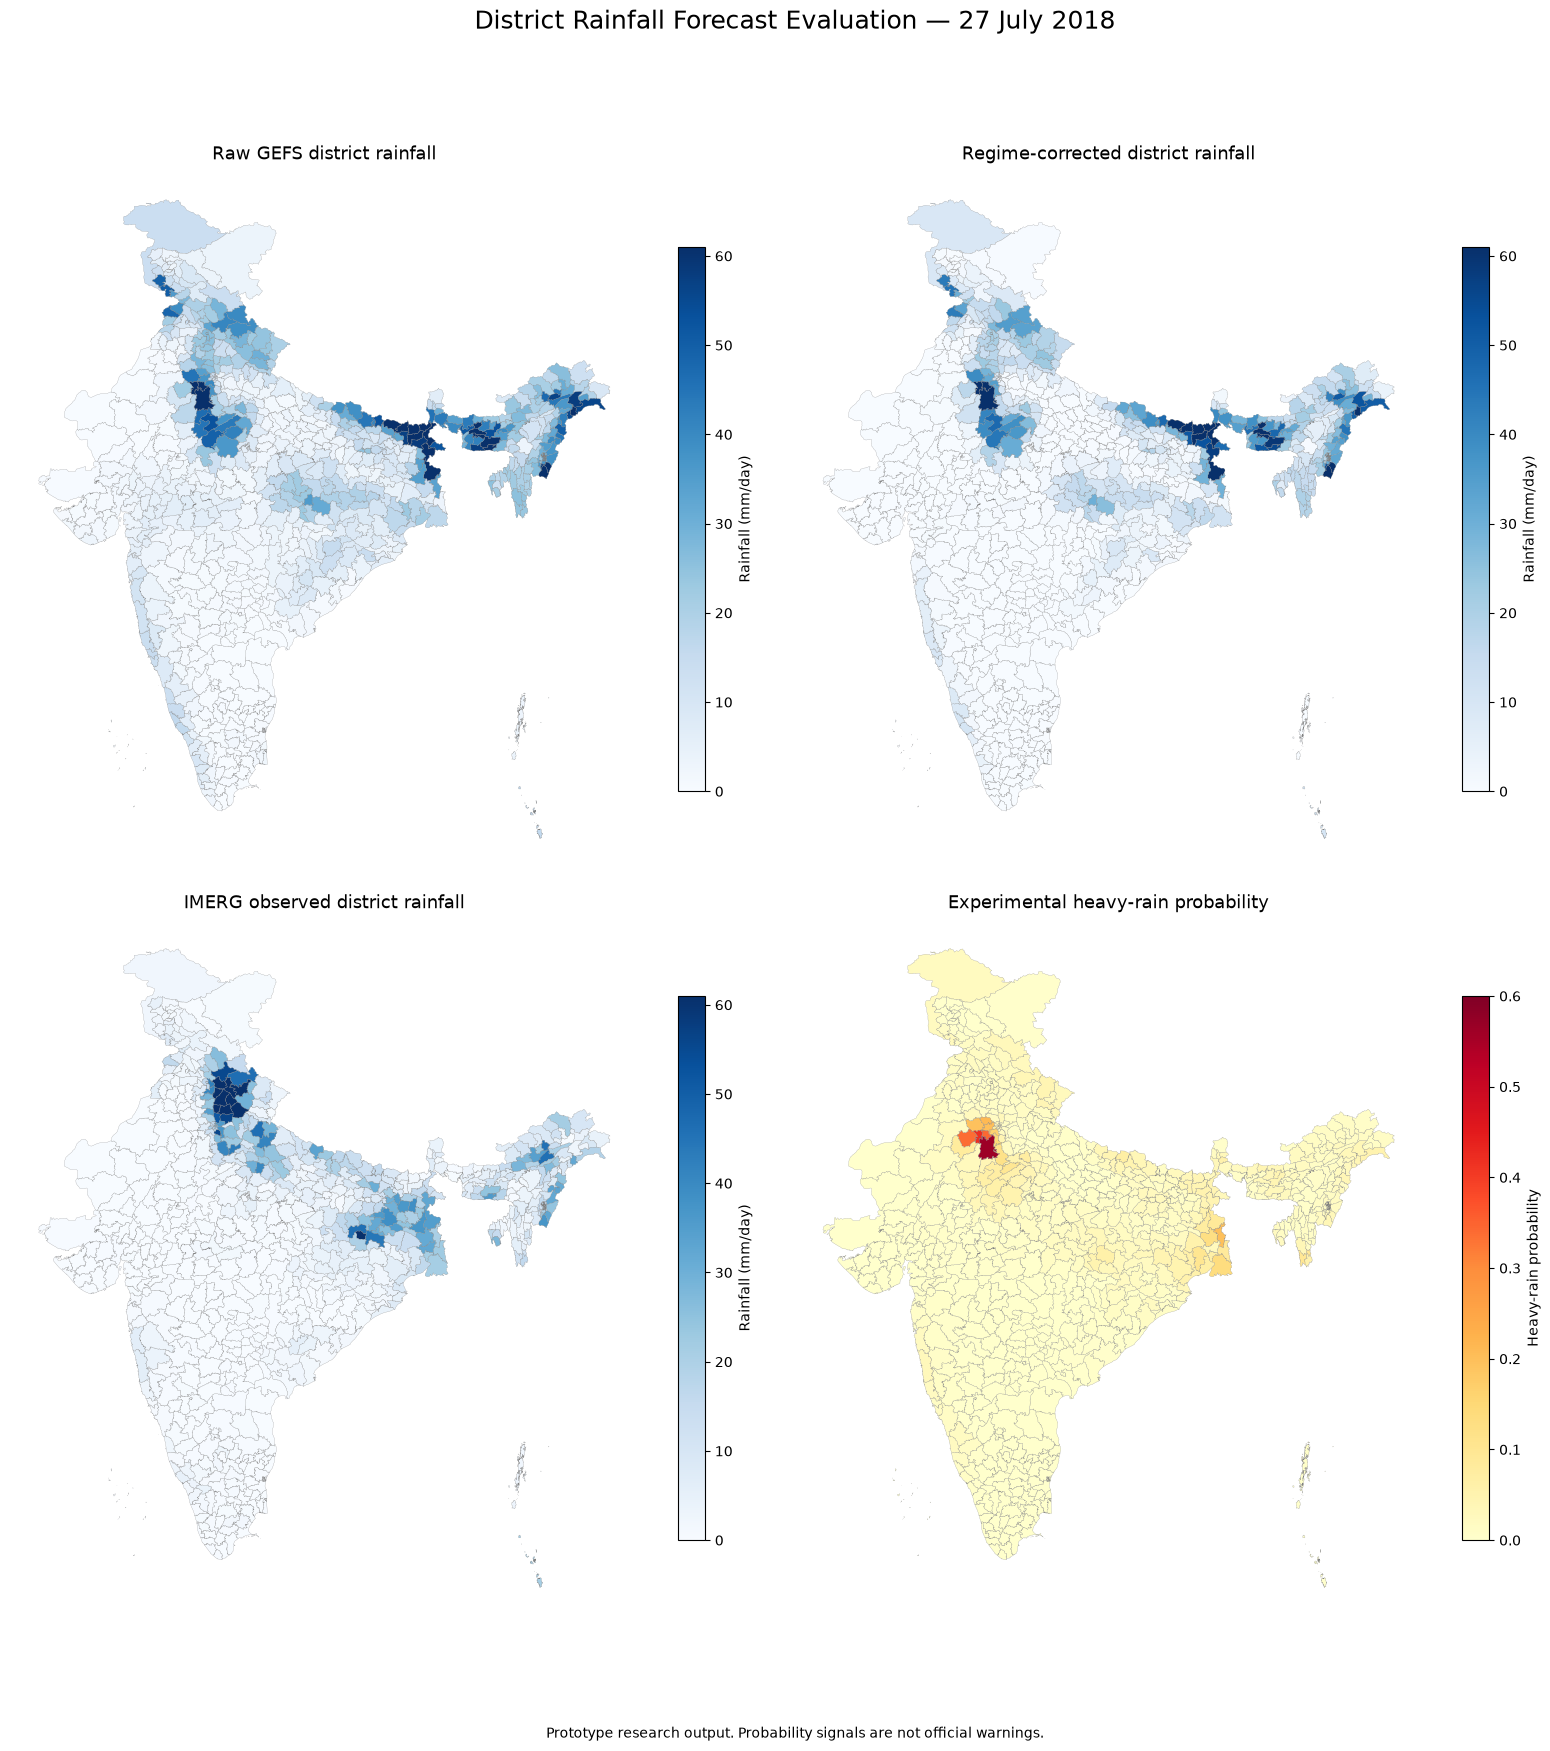

Saved: True
Location: Z:\Projects\monsoon-postprocessing\outputs\maps\district_forecast_20180727.png


In [26]:
rainfall_values = np.concatenate(
    [
        district_map["gefs_mean_mm"].dropna().values,
        district_map[
            "regime_corrected_mean_mm"
        ].dropna().values,
        district_map["observed_mean_mm"].dropna().values,
    ]
)

rainfall_colour_max = np.nanpercentile(
    rainfall_values,
    98,
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 18),
)

rainfall_maps = [
    (
        "gefs_mean_mm",
        "Raw GEFS district rainfall",
    ),
    (
        "regime_corrected_mean_mm",
        "Regime-corrected district rainfall",
    ),
    (
        "observed_mean_mm",
        "IMERG observed district rainfall",
    ),
]

for axis, (column, title) in zip(
    axes.flat[:3],
    rainfall_maps,
):
    district_map.plot(
        column=column,
        ax=axis,
        cmap="Blues",
        vmin=0,
        vmax=rainfall_colour_max,
        edgecolor="grey",
        linewidth=0.15,
        legend=True,
        legend_kwds={
            "label": "Rainfall (mm/day)",
            "shrink": 0.65,
        },
        missing_kwds={
            "color": "lightgrey",
        },
    )

    axis.set_title(title, fontsize=13)
    axis.set_axis_off()

district_map.plot(
    column="heavy_probability_max",
    ax=axes[1, 1],
    cmap="YlOrRd",
    vmin=0,
    vmax=0.60,
    edgecolor="grey",
    linewidth=0.15,
    legend=True,
    legend_kwds={
        "label": "Heavy-rain probability",
        "shrink": 0.65,
    },
    missing_kwds={
        "color": "lightgrey",
    },
)

axes[1, 1].set_title(
    "Experimental heavy-rain probability",
    fontsize=13,
)
axes[1, 1].set_axis_off()

fig.suptitle(
    f"District Rainfall Forecast Evaluation — "
    f"{SELECTED_DATE:%d %B %Y}",
    fontsize=18,
)

fig.text(
    0.5,
    0.02,
    "Prototype research output. Probability signals are not official warnings.",
    ha="center",
    fontsize=10,
)

plt.tight_layout(
    rect=[0, 0.04, 1, 0.96]
)

MAP_FOLDER = PROJECT_ROOT / "outputs" / "maps"
MAP_FOLDER.mkdir(parents=True, exist_ok=True)

MAP_FILE = (
    MAP_FOLDER
    / f"district_forecast_{SELECTED_DATE:%Y%m%d}.png"
)

plt.savefig(
    MAP_FILE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", MAP_FILE.exists())
print("Location:", MAP_FILE)

In [27]:
rainfall_columns = [
    "gefs_mean_mm",
    "regime_corrected_mean_mm",
    "observed_mean_mm",
]

all_rainfall_values = np.concatenate(
    [
        district_daily_corrected[column]
        .dropna()
        .values
        for column in rainfall_columns
    ]
)

rainfall_colour_max = np.nanpercentile(
    all_rainfall_values,
    98,
)

generated_maps = []

for forecast_date in sorted(
    district_daily_corrected["date"].unique()
):
    forecast_date = pd.Timestamp(forecast_date)

    daily_data = district_daily_corrected[
        district_daily_corrected["date"]
        == forecast_date
    ].copy()

    daily_map = districts.merge(
        daily_data[
            [
                "shapeID",
                "gefs_mean_mm",
                "regime_corrected_mean_mm",
                "observed_mean_mm",
                "heavy_probability_max",
            ]
        ],
        on="shapeID",
        how="left",
        validate="one_to_one",
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 18),
    )

    rainfall_maps = [
        (
            "gefs_mean_mm",
            "Raw GEFS district rainfall",
        ),
        (
            "regime_corrected_mean_mm",
            "Regime-corrected district rainfall",
        ),
        (
            "observed_mean_mm",
            "IMERG observed district rainfall",
        ),
    ]

    for axis, (column, title) in zip(
        axes.flat[:3],
        rainfall_maps,
    ):
        daily_map.plot(
            column=column,
            ax=axis,
            cmap="Blues",
            vmin=0,
            vmax=rainfall_colour_max,
            edgecolor="grey",
            linewidth=0.15,
            legend=True,
            legend_kwds={
                "label": "Rainfall (mm/day)",
                "shrink": 0.65,
            },
            missing_kwds={
                "color": "lightgrey",
            },
        )

        axis.set_title(title, fontsize=13)
        axis.set_axis_off()

    daily_map.plot(
        column="heavy_probability_max",
        ax=axes[1, 1],
        cmap="YlOrRd",
        vmin=0,
        vmax=0.60,
        edgecolor="grey",
        linewidth=0.15,
        legend=True,
        legend_kwds={
            "label": "Heavy-rain probability",
            "shrink": 0.65,
        },
        missing_kwds={
            "color": "lightgrey",
        },
    )

    axes[1, 1].set_title(
        "Experimental heavy-rain probability",
        fontsize=13,
    )
    axes[1, 1].set_axis_off()

    fig.suptitle(
        f"District Rainfall Forecast Evaluation — "
        f"{forecast_date:%d %B %Y}",
        fontsize=18,
    )

    fig.text(
        0.5,
        0.02,
        "Prototype research output. Probability signals are not official warnings.",
        ha="center",
        fontsize=10,
    )

    plt.tight_layout(
        rect=[0, 0.04, 1, 0.96]
    )

    output_file = (
        MAP_FOLDER
        / f"district_forecast_{forecast_date:%Y%m%d}.png"
    )

    plt.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight",
    )

    plt.close(fig)

    generated_maps.append(output_file)

print("Maps generated:", len(generated_maps))

for file in generated_maps:
    print(file.name, file.exists())

Maps generated: 5
district_forecast_20180727.png True
district_forecast_20180728.png True
district_forecast_20180729.png True
district_forecast_20180730.png True
district_forecast_20180731.png True


In [28]:
forecast_attributes = district_daily_corrected.drop(
    columns=["shapeName"]
).copy()

forecast_attributes["date"] = pd.to_datetime(
    forecast_attributes["date"]
).dt.strftime("%Y-%m-%d")

district_forecast_geo = districts[
    [
        "shapeID",
        "shapeName",
        "geometry",
    ]
].merge(
    forecast_attributes,
    on="shapeID",
    how="inner",
    validate="one_to_many",
)

GEOJSON_FILE = (
    PROCESSED_FOLDER
    / "district_regime_corrected_forecast.geojson"
)

district_forecast_geo.to_file(
    GEOJSON_FILE,
    driver="GeoJSON",
)

print("Saved:", GEOJSON_FILE.exists())
print("Location:", GEOJSON_FILE)
print("Rows:", len(district_forecast_geo))
print(
    "Districts:",
    district_forecast_geo["shapeID"].nunique(),
)
print(
    "Dates:",
    district_forecast_geo["date"].nunique(),
)

Saved: True
Location: Z:\Projects\monsoon-postprocessing\data\processed\district_regime_corrected_forecast.geojson
Rows: 3675
Districts: 735
Dates: 5
